
# Family-fix undercoverage diagnostics

This notebook focuses **only on pointwise undercoverage in the final double check**.

Project rule for this notebook:

- The target is **pointwise deployed coverage near 0.95**
- We care about whether the selected dictionary value `alpha*(x)` actually calibrates each test point in the **final deployed double check**
- Until the project focus changes, **overcoverage is not treated as the main issue**
- Diagnostics here focus on points where deployed coverage is **below** the nominal level

This notebook implements the 4 requested diagnostics:

1. **Undercovered points summary**
2. **All-10-alpha estimated coverage table** on the undercovered points
3. **Replication-level alpha\* frequency** on the undercovered points
4. **Failure-type classification** for the undercovered points

It also saves the 2 requested tables:

- `01_undercovered_points_summary.csv`
- `02_undercovered_all_alpha_estimated_coverage.csv`

and several additional helper outputs to a local output folder.


In [1]:

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

# Adjust if needed
RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\familyfix\results")
OUTPUT_DIR = RESULTS_DIR / "undercoverage_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR


(WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results/undercoverage_diagnostics'))

In [2]:

DEPLOY_PATTERN = "deploy_final_rep*_J*.csv"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))

def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

deploy_files = sorted(RESULTS_DIR.glob(DEPLOY_PATTERN), key=parse_rep_id)
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_files)} deploy files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_PATTERN} were found in {RESULTS_DIR}")


Found 100 deploy files
Found 100 pointwise coverage files
Found 100 alpha-star files
Found 100 meta files


In [3]:

def selected_estimated_coverage(coverage_df: pd.DataFrame, alpha_star_vec: np.ndarray) -> np.ndarray:
    out = np.empty(len(alpha_star_vec), dtype=float)
    alpha_cols = [c for c in coverage_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)

    for j, a in enumerate(alpha_star_vec):
        col = f"alpha_{float(a):.4f}"
        if col not in coverage_df.columns:
            idx = int(np.argmin(np.abs(alpha_vals - float(a))))
            col = alpha_cols[idx]
        out[j] = float(coverage_df.iloc[j][col])
    return out

records = []
x_ref = None
true_f_ref = None
ci_level = None
alpha_cols_ref = None
alpha_vals_ref = None

for deploy_path in deploy_files:
    rep_id = parse_rep_id(deploy_path)
    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))

    rec = {
        "rep_id": rep_id,
        "deploy_df": deploy_df,
        "coverage_df": None,
        "alpha_star_df": None,
        "selected_est_cov": None,
        "meta": meta,
    }

    cov_path = coverage_files.get(rep_id)
    if cov_path is not None:
        cov_df = pd.read_csv(cov_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"coverage x-grid mismatch in rep {rep_id}")

        alpha_cols = [c for c in cov_df.columns if c.startswith("alpha_")]
        alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
        order = np.argsort(alpha_vals)
        alpha_cols = [alpha_cols[i] for i in order]
        alpha_vals = alpha_vals[order]
        cov_df = cov_df[["x"] + alpha_cols].copy()

        rec["coverage_df"] = cov_df

        if alpha_cols_ref is None:
            alpha_cols_ref = alpha_cols
            alpha_vals_ref = alpha_vals
        else:
            if len(alpha_cols_ref) != len(alpha_cols):
                raise ValueError(f"Alpha-column count mismatch in rep {rep_id}")
            if not np.allclose(alpha_vals_ref, alpha_vals):
                raise ValueError(f"Alpha grid mismatch in rep {rep_id}")

    alpha_path = alpha_star_files.get(rep_id)
    if alpha_path is not None:
        alpha_df = pd.read_csv(alpha_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"alpha_star x-grid mismatch in rep {rep_id}")
        rec["alpha_star_df"] = alpha_df

    if rec["coverage_df"] is not None:
        if rec["alpha_star_df"] is not None:
            alpha_star_vec = rec["alpha_star_df"]["alpha_star"].to_numpy(dtype=float)
        else:
            alpha_star_vec = deploy_df["alpha_star"].to_numpy(dtype=float)
        rec["selected_est_cov"] = selected_estimated_coverage(rec["coverage_df"], alpha_star_vec)

    records.append(rec)

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")
print(f"Alpha grid: {alpha_vals_ref}")


Loaded 100 replications
Nominal CI level from meta: 0.95
Alpha grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [4]:

rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)
A = len(alpha_vals_ref)

hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])
alpha_star_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])

have_est_cov = all(r["selected_est_cov"] is not None for r in records)
if not have_est_cov:
    raise ValueError("Some replications are missing pointwise coverage / selected estimated coverage.")

est_cov_selected_mat = np.vstack([r["selected_est_cov"] for r in records])
est_cov_all_tensor = np.stack(
    [r["coverage_df"][alpha_cols_ref].to_numpy(dtype=float) for r in records],
    axis=0,
)  # shape (R, J, A)

pointwise_deploy_cov = hit_mat.mean(axis=0)
pointwise_deploy_sd = hit_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)
pointwise_deploy_se = pointwise_deploy_sd / np.sqrt(max(R, 1))

pointwise_alpha_star_mean = alpha_star_mat.mean(axis=0)
pointwise_alpha_star_sd = alpha_star_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)

pointwise_selected_est_cov = est_cov_selected_mat.mean(axis=0)
pointwise_selected_est_cov_sd = est_cov_selected_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)

pointwise_table = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "deploy_coverage": pointwise_deploy_cov,
    "deploy_sd_across_rep_hits": pointwise_deploy_sd,
    "deploy_se": pointwise_deploy_se,
    "selected_est_coverage": pointwise_selected_est_cov,
    "selected_est_coverage_sd": pointwise_selected_est_cov_sd,
    "deploy_minus_selected_est": pointwise_deploy_cov - pointwise_selected_est_cov,
    "alpha_star_mean": pointwise_alpha_star_mean,
    "alpha_star_sd": pointwise_alpha_star_sd,
})
if ci_level is not None:
    pointwise_table["nominal"] = float(ci_level)
    pointwise_table["deploy_minus_nominal"] = pointwise_table["deploy_coverage"] - float(ci_level)
    pointwise_table["selected_est_minus_nominal"] = pointwise_table["selected_est_coverage"] - float(ci_level)

pointwise_table.head()


,x,true_f,deploy_coverage,deploy_sd_across_rep_hits,deploy_se,selected_est_coverage,selected_est_coverage_sd,deploy_minus_selected_est,alpha_star_mean,alpha_star_sd,nominal,deploy_minus_nominal,selected_est_minus_nominal
0,-2.500000,0.173318,0.95,0.219043,0.021904,0.9607,0.029033,-0.0107,0.545,0.332841,0.95,0.00,0.0107
1,-2.397959,-0.291511,1.00,0.000000,0.000000,0.9790,0.017552,0.0210,0.919,0.192640,0.95,0.05,0.0290
2,-2.295918,-0.547295,0.88,0.326599,0.032660,0.9707,0.017538,-0.0907,0.832,0.253811,0.95,-0.07,0.0207
3,-2.193878,-0.460571,0.87,0.337998,0.033800,0.9644,0.016226,-0.0944,0.698,0.291281,0.95,-0.08,0.0144
4,-2.091837,-0.045550,1.00,0.000000,0.000000,0.9818,0.017831,0.0182,0.975,0.097830,0.95,0.05,0.0318



## Diagnostic 1: undercovered points summary

These are the points where the **final deployed double-check coverage** is below nominal.
This is the main table to inspect first.


In [5]:

nominal = float(ci_level) if ci_level is not None else 0.95
under_mask = pointwise_table["deploy_coverage"] < nominal
under_idx = np.flatnonzero(under_mask.to_numpy())
U = len(under_idx)

print(f"Nominal target: {nominal:.4f}")
print(f"Undercovered points: {U} / {J}")

undercovered_summary = pointwise_table.loc[under_mask, [
    "x",
    "true_f",
    "deploy_coverage",
    "selected_est_coverage",
    "deploy_minus_selected_est",
    "alpha_star_mean",
    "alpha_star_sd",
]].copy()

undercovered_summary["gap_to_nominal"] = nominal - undercovered_summary["deploy_coverage"]
undercovered_summary["selected_est_gap_to_nominal"] = nominal - undercovered_summary["selected_est_coverage"]
undercovered_summary = undercovered_summary.sort_values(
    ["gap_to_nominal", "x"], ascending=[False, True]
).reset_index(drop=True)

undercovered_summary.to_csv(OUTPUT_DIR / "01_undercovered_points_summary.csv", index=False)
undercovered_summary


Nominal target: 0.9500
Undercovered points: 9 / 50


,x,true_f,deploy_coverage,selected_est_coverage,deploy_minus_selected_est,alpha_star_mean,alpha_star_sd,gap_to_nominal,selected_est_gap_to_nominal
0,-1.887755,1.055191,0.84,0.9672,-0.1272,0.755,0.249596,0.11,-0.0172
1,-1.581633,0.506969,0.84,0.9828,-0.1428,0.961,0.116250,0.11,-0.0328
2,-2.193878,-0.460571,0.87,0.9644,-0.0944,0.698,0.291281,0.08,-0.0144
3,-2.295918,-0.547295,0.88,0.9707,-0.0907,0.832,0.253811,0.07,-0.0207
4,-1.989796,0.539654,0.89,0.9874,-0.0974,0.987,0.067652,0.06,-0.0374
5,-1.479592,-0.262983,0.91,0.9650,-0.0550,0.782,0.243036,0.04,-0.0150
6,-1.173469,-1.351151,0.92,0.9896,-0.0696,0.976,0.099615,0.03,-0.0396
7,2.091837,1.045520,0.94,0.9672,-0.0272,0.746,0.275395,0.01,-0.0172
8,2.500000,0.173318,0.94,0.9792,-0.0392,0.897,0.217634,0.01,-0.0292


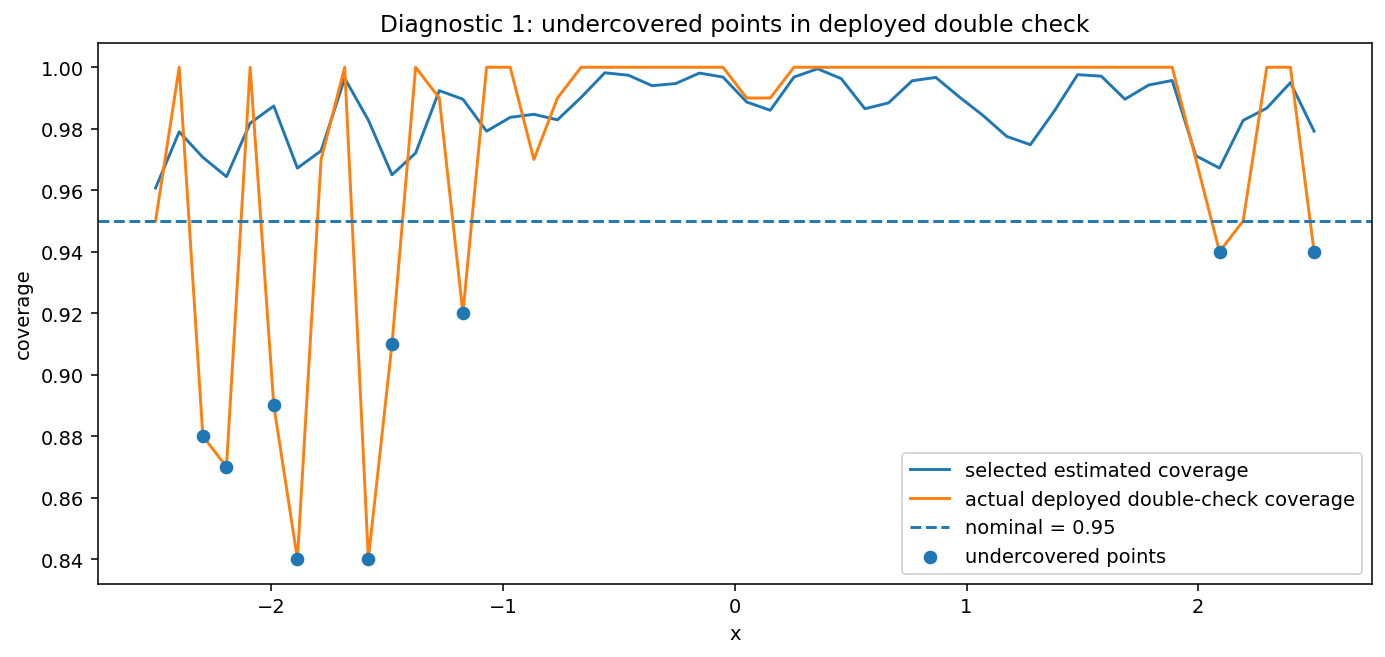

In [6]:

plt.figure(figsize=(10, 4.8))
plt.plot(pointwise_table["x"], pointwise_table["selected_est_coverage"], label="selected estimated coverage")
plt.plot(pointwise_table["x"], pointwise_table["deploy_coverage"], label="actual deployed double-check coverage")
plt.axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
if U > 0:
    plt.scatter(
        pointwise_table.loc[under_mask, "x"],
        pointwise_table.loc[under_mask, "deploy_coverage"],
        label="undercovered points",
        zorder=3,
    )
plt.xlabel("x")
plt.ylabel("coverage")
plt.title("Diagnostic 1: undercovered points in deployed double check")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_undercovered_points_plot.png", bbox_inches="tight")
plt.show()



## Diagnostic 2: all-10-alpha estimated coverage table on the undercovered points

For each undercovered test point, this section aggregates the estimated split-bootstrap coverage
for **every alpha in the dictionary**.

This answers the question:

- Is there already a candidate alpha in the dictionary whose **estimated** coverage is near 0.95?
- Or does the dictionary itself fail to offer a plausible candidate on that point?


In [7]:

alpha_mean_mat = est_cov_all_tensor.mean(axis=0)  # shape (J, A)
alpha_sd_mat = est_cov_all_tensor.std(axis=0, ddof=1) if R > 1 else np.zeros((J, A))

all_alpha_mean_df = pd.DataFrame(alpha_mean_mat, columns=[f"alpha_{a:.4f}" for a in alpha_vals_ref])
all_alpha_sd_df = pd.DataFrame(alpha_sd_mat, columns=[f"alpha_{a:.4f}_sd" for a in alpha_vals_ref])

all_alpha_summary = pd.concat(
    [
        pointwise_table[["x", "true_f", "deploy_coverage", "selected_est_coverage", "deploy_minus_selected_est", "alpha_star_mean", "alpha_star_sd"]].reset_index(drop=True),
        all_alpha_mean_df.reset_index(drop=True),
    ],
    axis=1,
)

undercovered_all_alpha = all_alpha_summary.loc[under_mask].copy()

alpha_only_cols = [f"alpha_{a:.4f}" for a in alpha_vals_ref]
alpha_only_mat = undercovered_all_alpha[alpha_only_cols].to_numpy(dtype=float)

closest_idx = np.argmin(np.abs(alpha_only_mat - nominal), axis=1)
best_alpha_by_est_mean = alpha_vals_ref[closest_idx]
best_alpha_est_mean = alpha_only_mat[np.arange(U), closest_idx]
best_alpha_est_abs_err = np.abs(best_alpha_est_mean - nominal)

undercovered_all_alpha["best_alpha_by_estimated_mean"] = best_alpha_by_est_mean
undercovered_all_alpha["best_alpha_estimated_coverage"] = best_alpha_est_mean
undercovered_all_alpha["best_alpha_abs_error_to_nominal"] = best_alpha_est_abs_err

undercovered_all_alpha.to_csv(OUTPUT_DIR / "02_undercovered_all_alpha_estimated_coverage.csv", index=False)

# long-format helper table
undercovered_all_alpha_long = undercovered_all_alpha[["x", "deploy_coverage", "selected_est_coverage", "alpha_star_mean"]].copy()
undercovered_all_alpha_long["row_id"] = np.arange(U)
undercovered_all_alpha_long = undercovered_all_alpha_long.loc[undercovered_all_alpha_long.index.repeat(A)].reset_index(drop=True)
undercovered_all_alpha_long["alpha"] = np.tile(alpha_vals_ref, U)
undercovered_all_alpha_long["estimated_coverage_mean"] = alpha_only_mat.reshape(-1)
undercovered_all_alpha_long["abs_error_to_nominal"] = np.abs(undercovered_all_alpha_long["estimated_coverage_mean"] - nominal)
undercovered_all_alpha_long.to_csv(OUTPUT_DIR / "02_undercovered_all_alpha_estimated_coverage_long.csv", index=False)

undercovered_all_alpha


,x,true_f,deploy_coverage,selected_est_coverage,deploy_minus_selected_est,alpha_star_mean,alpha_star_sd,alpha_0.1000,alpha_0.2000,alpha_0.3000,alpha_0.4000,alpha_0.5000,alpha_0.6000,alpha_0.7000,alpha_0.8000,alpha_0.9000,alpha_1.0000,best_alpha_by_estimated_mean,best_alpha_estimated_coverage,best_alpha_abs_error_to_nominal
2,-2.295918,-0.547295,0.88,0.9707,-0.0907,0.832,0.253811,1.0000,0.9967,0.9910,0.9816,0.9715,0.9602,0.9505,0.9404,0.9310,0.9212,0.7,0.9505,0.0005
3,-2.193878,-0.460571,0.87,0.9644,-0.0944,0.698,0.291281,0.9990,0.9916,0.9790,0.9631,0.9475,0.9311,0.9160,0.9045,0.8928,0.8815,0.5,0.9475,0.0025
5,-1.989796,0.539654,0.89,0.9874,-0.0974,0.987,0.067652,1.0000,0.9999,0.9997,0.9996,0.9987,0.9959,0.9928,0.9896,0.9852,0.9795,1.0,0.9795,0.0295
6,-1.887755,1.055191,0.84,0.9672,-0.1272,0.755,0.249596,1.0000,0.9985,0.9919,0.9802,0.9651,0.9478,0.9325,0.9172,0.9034,0.8895,0.6,0.9478,0.0022
9,-1.581633,0.506969,0.84,0.9828,-0.1428,0.961,0.116250,1.0000,1.0000,1.0000,0.9986,0.9963,0.9923,0.9876,0.9813,0.9736,0.9666,1.0,0.9666,0.0166
10,-1.479592,-0.262983,0.91,0.9650,-0.0550,0.782,0.243036,1.0000,0.9986,0.9928,0.9824,0.9660,0.9510,0.9350,0.9241,0.9096,0.8950,0.6,0.9510,0.0010
13,-1.173469,-1.351151,0.92,0.9896,-0.0696,0.976,0.099615,1.0000,1.0000,0.9999,0.9994,0.9970,0.9933,0.9895,0.9848,0.9803,0.9758,1.0,0.9758,0.0258
45,2.091837,1.045520,0.94,0.9672,-0.0272,0.746,0.275395,1.0000,0.9966,0.9864,0.9732,0.9538,0.9381,0.9227,0.9098,0.9001,0.8891,0.5,0.9538,0.0038
49,2.500000,0.173318,0.94,0.9792,-0.0392,0.897,0.217634,0.9992,0.9911,0.9820,0.9752,0.9689,0.9633,0.9561,0.9503,0.9439,0.9383,0.8,0.9503,0.0003


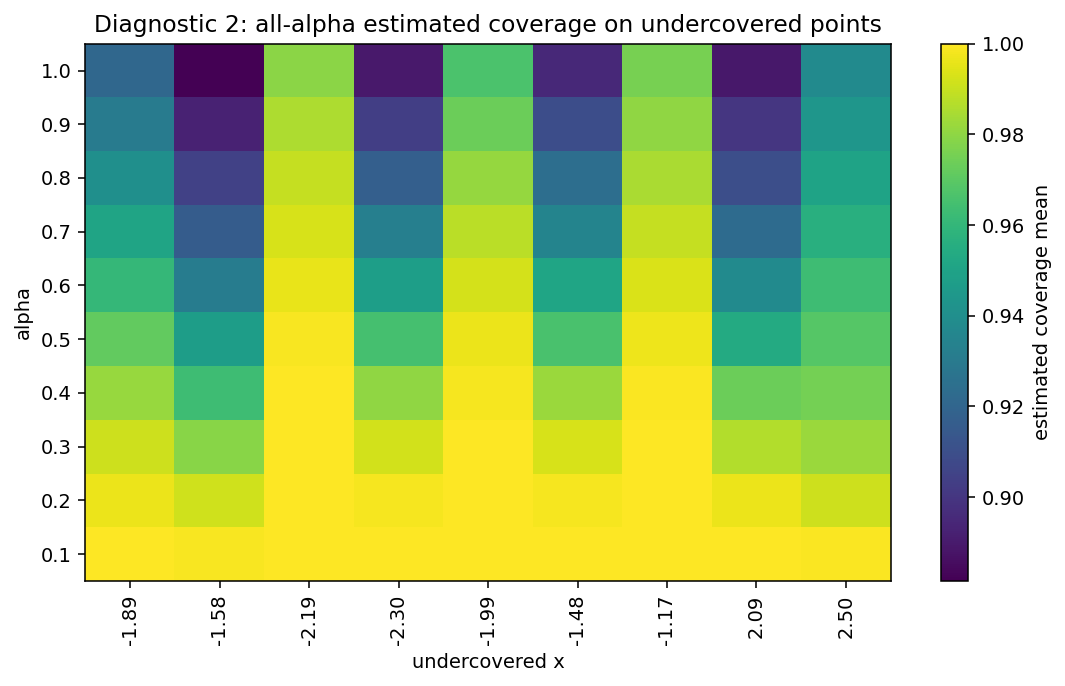

In [8]:

if U > 0:
    plt.figure(figsize=(max(8, 0.5 * U), 5.0))
    plt.imshow(alpha_only_mat.T, aspect="auto", origin="lower")
    plt.colorbar(label="estimated coverage mean")
    plt.yticks(np.arange(A), [f"{a:.1f}" for a in alpha_vals_ref])
    plt.xticks(np.arange(U), [f"{x:.2f}" for x in undercovered_summary["x"]], rotation=90)
    plt.xlabel("undercovered x")
    plt.ylabel("alpha")
    plt.title("Diagnostic 2: all-alpha estimated coverage on undercovered points")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_undercovered_all_alpha_heatmap.png", bbox_inches="tight")
    plt.show()



## Diagnostic 3: replication-level alpha\* frequency on the undercovered points

This checks whether the selected `alpha*(x)` is stable or unstable across replications
on the points that ultimately remain undercovered.


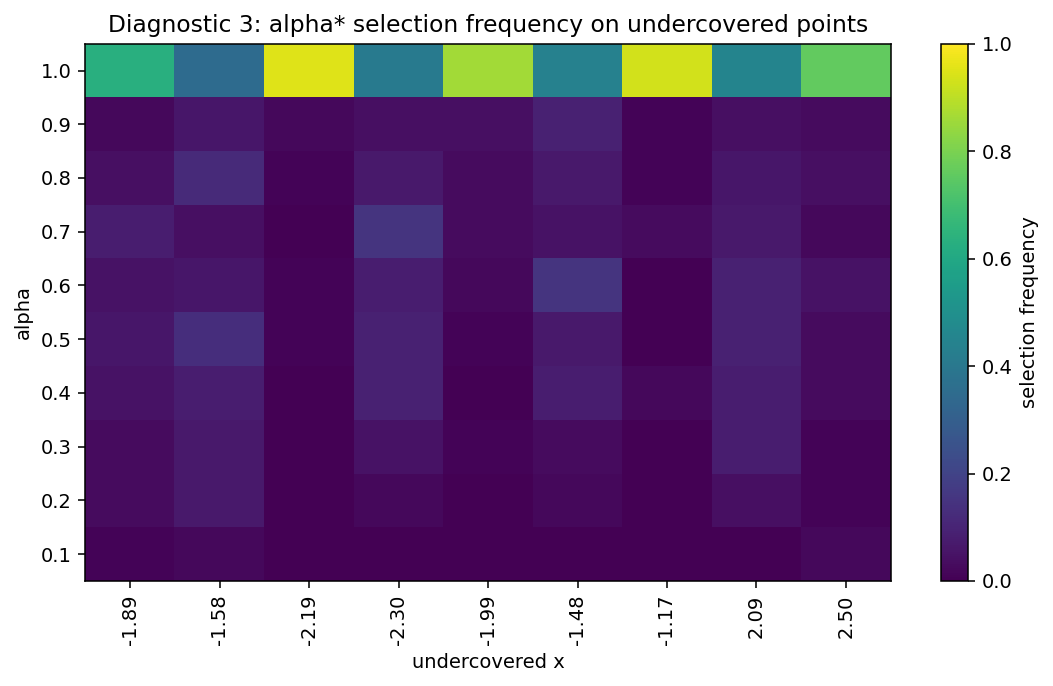

,x,alpha,count,frequency
0,-2.295918,0.1,1,0.01
1,-2.295918,0.2,3,0.03
2,-2.295918,0.3,3,0.03
3,-2.295918,0.4,5,0.05
4,-2.295918,0.5,6,0.06


In [9]:

if U > 0:
    freq_rows = []
    alpha_freq_mat = np.zeros((U, A), dtype=float)

    for ui, j in enumerate(under_idx):
        selected_here = alpha_star_mat[:, j]
        for ai, a in enumerate(alpha_vals_ref):
            count = int(np.sum(np.isclose(selected_here, a)))
            freq = count / R
            alpha_freq_mat[ui, ai] = freq
            freq_rows.append({
                "x": float(x_ref[j]),
                "alpha": float(a),
                "count": count,
                "frequency": freq,
            })

    alpha_freq_df = pd.DataFrame(freq_rows)
    alpha_freq_df.to_csv(OUTPUT_DIR / "03_undercovered_alpha_star_frequency_long.csv", index=False)

    plt.figure(figsize=(max(8, 0.5 * U), 5.0))
    plt.imshow(alpha_freq_mat.T, aspect="auto", origin="lower", vmin=0.0, vmax=1.0)
    plt.colorbar(label="selection frequency")
    plt.yticks(np.arange(A), [f"{a:.1f}" for a in alpha_vals_ref])
    plt.xticks(np.arange(U), [f"{x:.2f}" for x in undercovered_summary["x"]], rotation=90)
    plt.xlabel("undercovered x")
    plt.ylabel("alpha")
    plt.title("Diagnostic 3: alpha* selection frequency on undercovered points")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_undercovered_alpha_star_frequency_heatmap.png", bbox_inches="tight")
    plt.show()

alpha_freq_df.head() if U > 0 else None



## Diagnostic 4: failure-type classification on the undercovered points

This classification is intentionally aligned with the current project focus.

For an undercovered point:

- If `deploy_minus_selected_est` is strongly negative, then the split-bootstrap estimate looked better than what the final deployed double check delivered.  
  We label this **transfer_mismatch_priority**.
- Otherwise, if even the best estimated alpha in the dictionary is still not close to nominal,  
  we label this **dictionary_support_priority**.
- Otherwise, the point is undercovered but not strongly diagnostic in either direction.  
  We label this **mild_or_mixed_undercoverage**.

You can adjust the threshold below if needed.


          x  deploy_coverage  selected_est_coverage  \
0 -1.887755             0.84                 0.9672   
1 -1.581633             0.84                 0.9828   
2 -2.193878             0.87                 0.9644   
3 -2.295918             0.88                 0.9707   
4 -1.989796             0.89                 0.9874   
5 -1.479592             0.91                 0.9650   
6 -1.173469             0.92                 0.9896   
7  2.091837             0.94                 0.9672   
8  2.500000             0.94                 0.9792   

   deploy_minus_selected_est  best_alpha_by_estimated_mean  \
0                    -0.1272                           0.6   
1                    -0.1428                           1.0   
2                    -0.0944                           0.5   
3                    -0.0907                           0.7   
4                    -0.0974                           1.0   
5                    -0.0550                           0.6   
6              

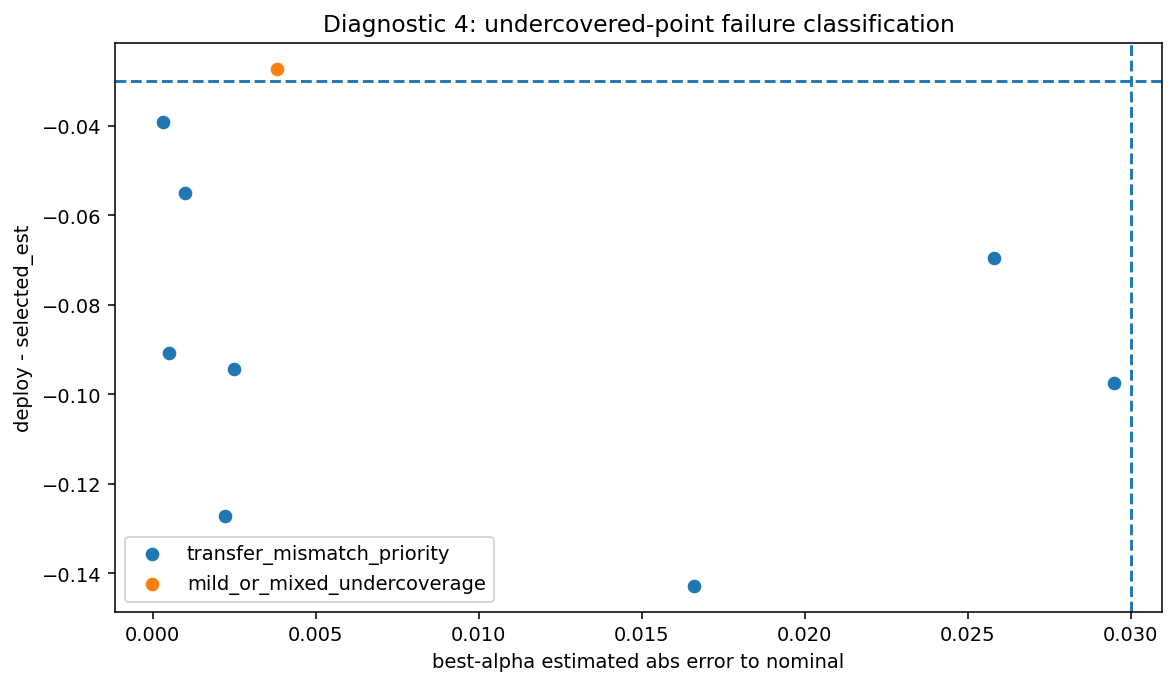

In [10]:

gap_tol = 0.03

if U > 0:
    failure_df = undercovered_all_alpha[[
        "x",
        "true_f",
        "deploy_coverage",
        "selected_est_coverage",
        "deploy_minus_selected_est",
        "alpha_star_mean",
        "alpha_star_sd",
        "best_alpha_by_estimated_mean",
        "best_alpha_estimated_coverage",
        "best_alpha_abs_error_to_nominal",
    ]].copy()

    classes = []
    for _, row in failure_df.iterrows():
        if row["deploy_minus_selected_est"] < -gap_tol:
            cls = "transfer_mismatch_priority"
        elif row["best_alpha_abs_error_to_nominal"] > gap_tol:
            cls = "dictionary_support_priority"
        else:
            cls = "mild_or_mixed_undercoverage"
        classes.append(cls)

    failure_df["failure_type"] = classes
    failure_df["severity"] = nominal - failure_df["deploy_coverage"]
    failure_df = failure_df.sort_values(["severity", "x"], ascending=[False, True]).reset_index(drop=True)
    failure_df.to_csv(OUTPUT_DIR / "04_undercovered_failure_classification.csv", index=False)

    print(failure_df[[
        "x",
        "deploy_coverage",
        "selected_est_coverage",
        "deploy_minus_selected_est",
        "best_alpha_by_estimated_mean",
        "best_alpha_estimated_coverage",
        "best_alpha_abs_error_to_nominal",
        "failure_type",
    ]])

    plt.figure(figsize=(8.5, 5.0))
    xvals = failure_df["best_alpha_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = failure_df["deploy_minus_selected_est"].to_numpy(dtype=float)

    class_order = [
        "transfer_mismatch_priority",
        "dictionary_support_priority",
        "mild_or_mixed_undercoverage",
    ]
    for cls in class_order:
        mask = failure_df["failure_type"] == cls
        if mask.any():
            plt.scatter(
                xvals[mask.to_numpy()],
                yvals[mask.to_numpy()],
                label=cls,
            )

    plt.axvline(gap_tol, linestyle="--")
    plt.axhline(-gap_tol, linestyle="--")
    plt.xlabel("best-alpha estimated abs error to nominal")
    plt.ylabel("deploy - selected_est")
    plt.title("Diagnostic 4: undercovered-point failure classification")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_undercovered_failure_classification_scatter.png", bbox_inches="tight")
    plt.show()



## Quick text summary

This final cell prints the key outputs you will likely reference first.


In [11]:

print("==== UNDERCOVERAGE DIAGNOSTIC SUMMARY ====")
print(f"R = {R}")
print(f"J = {J}")
print(f"Nominal = {nominal:.4f}")
print(f"Undercovered points = {U}")

if U > 0:
    worst = undercovered_summary.iloc[0]
    print()
    print("Worst undercovered point:")
    print(f"  x = {worst['x']:.6f}")
    print(f"  deploy_coverage = {worst['deploy_coverage']:.6f}")
    print(f"  selected_est_coverage = {worst['selected_est_coverage']:.6f}")
    print(f"  deploy_minus_selected_est = {worst['deploy_minus_selected_est']:.6f}")
    print(f"  alpha_star_mean = {worst['alpha_star_mean']:.6f}")
    print(f"  alpha_star_sd = {worst['alpha_star_sd']:.6f}")

    print()
    print("Failure type counts:")
    print(pd.read_csv(OUTPUT_DIR / "04_undercovered_failure_classification.csv")["failure_type"].value_counts())

print()
print(f"Saved outputs to: {OUTPUT_DIR}")
print("Main requested tables:")
print(f"  {OUTPUT_DIR / '01_undercovered_points_summary.csv'}")
print(f"  {OUTPUT_DIR / '02_undercovered_all_alpha_estimated_coverage.csv'}")


==== UNDERCOVERAGE DIAGNOSTIC SUMMARY ====
R = 100
J = 50
Nominal = 0.9500
Undercovered points = 9

Worst undercovered point:
  x = -1.887755
  deploy_coverage = 0.840000
  selected_est_coverage = 0.967200
  deploy_minus_selected_est = -0.127200
  alpha_star_mean = 0.755000
  alpha_star_sd = 0.249596

Failure type counts:
failure_type
transfer_mismatch_priority     8
mild_or_mixed_undercoverage    1
Name: count, dtype: int64

Saved outputs to: C:\Users\yangy\26 spring\with reference\familyfix\results\undercoverage_diagnostics
Main requested tables:
  C:\Users\yangy\26 spring\with reference\familyfix\results\undercoverage_diagnostics\01_undercovered_points_summary.csv
  C:\Users\yangy\26 spring\with reference\familyfix\results\undercoverage_diagnostics\02_undercovered_all_alpha_estimated_coverage.csv
